In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

In [3]:
data_dir = "LIDC-IDRI-slices"

images = []
labels = []

for patient in os.listdir(data_dir):
    patient_path = os.path.join(data_dir, patient)
    for nodule in os.listdir(patient_path):
        nodule_path = os.path.join(patient_path, nodule)
        img_path = os.path.join(nodule_path, "images")
        
        # label: nodule-0 = benign(0), nodule-1+ = malignant(1)
        label = 0 if nodule == "nodule-0" else 1
        
        for img_file in os.listdir(img_path):
            if img_file.endswith(".png"):
                img = Image.open(os.path.join(img_path, img_file)).convert("RGB")
                images.append(img)
                labels.append(label)

print(f"Total images: {len(images)}, Labels: {len(labels)}")

Total images: 15548, Labels: 15548


In [4]:
class NoduleDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

In [5]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

train_ds = NoduleDataset(X_train, y_train, transform)
test_ds  = NoduleDataset(X_test,  y_test,  transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=32)

print(f"Train: {len(train_ds)}, Test: {len(test_ds)}")

print(f"Train Batch: {len(train_loader)}, Test Batch: {len(test_loader)}")

Train: 12438, Test: 3110
Train Batch: 389, Test Batch: 98


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 2)  # 2 classes
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

cpu


In [7]:
train_acc_list = []
val_acc_list = []
train_loss_list = []
val_loss_list = []

for epoch in range(10):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        preds = torch.argmax(out, dim=1)
        correct += (preds == lbls).sum().item()
        total += lbls.size(0)
    train_acc = correct / total * 100

    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out = model(imgs)
            loss = criterion(out, lbls)
            val_loss += loss.item()
            preds = torch.argmax(out, dim=1)
            val_correct += (preds == lbls).sum().item()
            val_total += lbls.size(0)
    val_acc = val_correct / val_total * 100

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    train_loss_list.append(total_loss / len(train_loader))
    val_loss_list.append(val_loss / len(test_loader))

    print(f"Epoch {epoch+1}/10 | Loss: {total_loss/len(train_loader):.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss/len(test_loader):.4f} | Val Acc: {val_acc:.2f}%")

Epoch 1/10 | Loss: 0.6359 | Train Acc: 68.44% | Val Loss: 0.5590 | Val Acc: 74.34%
Epoch 2/10 | Loss: 0.4943 | Train Acc: 77.17% | Val Loss: 0.4472 | Val Acc: 79.20%
Epoch 3/10 | Loss: 0.3544 | Train Acc: 84.94% | Val Loss: 0.4610 | Val Acc: 79.68%
Epoch 4/10 | Loss: 0.2418 | Train Acc: 90.46% | Val Loss: 0.2635 | Val Acc: 89.74%
Epoch 5/10 | Loss: 0.1604 | Train Acc: 94.03% | Val Loss: 0.2436 | Val Acc: 89.94%
Epoch 6/10 | Loss: 0.1008 | Train Acc: 96.35% | Val Loss: 0.1916 | Val Acc: 92.25%
Epoch 7/10 | Loss: 0.0734 | Train Acc: 97.19% | Val Loss: 0.1725 | Val Acc: 93.63%
Epoch 8/10 | Loss: 0.0638 | Train Acc: 97.84% | Val Loss: 0.2279 | Val Acc: 91.99%
Epoch 9/10 | Loss: 0.0541 | Train Acc: 98.15% | Val Loss: 0.1421 | Val Acc: 95.18%
Epoch 10/10 | Loss: 0.0478 | Train Acc: 98.34% | Val Loss: 0.1459 | Val Acc: 95.31%


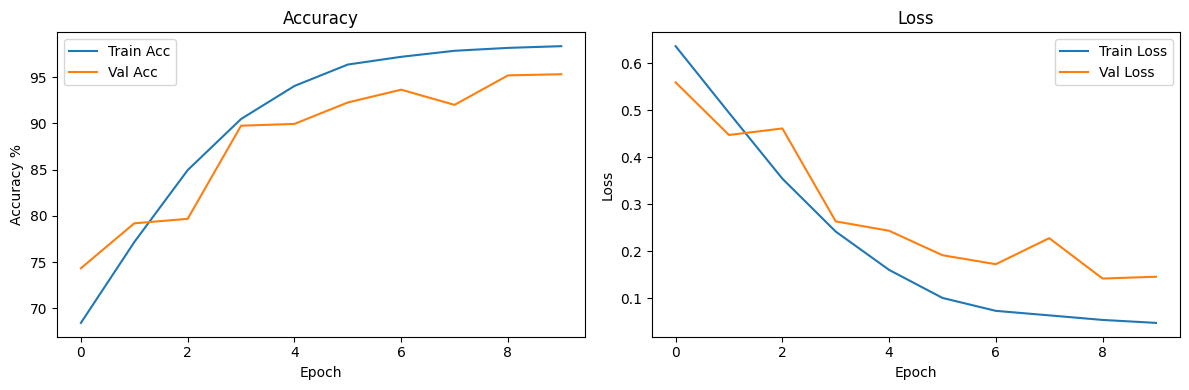

In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_acc_list, label="Train Acc")
plt.plot(val_acc_list, label="Val Acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy %")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_loss_list, label="Train Loss")
plt.plot(val_loss_list, label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        out = model(imgs)
        preds = torch.argmax(out, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(lbls.numpy())

print(classification_report(all_labels, all_preds, target_names=["Benign", "Malignant"]))

              precision    recall  f1-score   support

      Benign       0.95      0.92      0.94      1157
   Malignant       0.96      0.97      0.96      1953

    accuracy                           0.95      3110
   macro avg       0.95      0.95      0.95      3110
weighted avg       0.95      0.95      0.95      3110



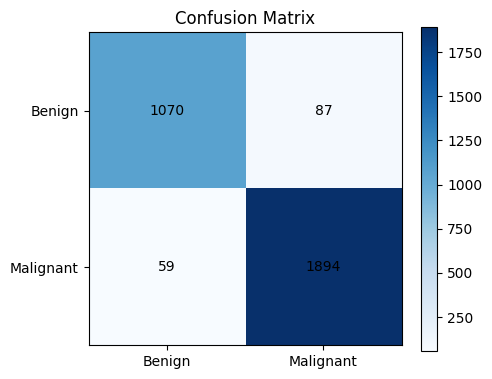

In [10]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], ["Benign", "Malignant"])
plt.yticks([0,1], ["Benign", "Malignant"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha='center', va='center', color='black')
plt.tight_layout()
plt.show()